In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from flonacomldft.utils.io_utils import (
    get_path,
    get_project_path,
    load_pickle_file,
    load_csv_file,
)

from flonacomldft.internal_coordinates import Coordinates_mapping
from flonacomldft.utils.plots import (
    set_plot_sequential_data,
    plot_energy_surface,
    plot_energy_histogram,
)

from flonacomldft.utils.data_processing import load_datasets

from flonacomldft.utils.diagnostics import (
    R_hat,
    Target_Log_Prob,
)

from numpy.lib.stride_tricks import sliding_window_view

import matplotlib.pylab as pylab

size=16
params = {'legend.fontsize': size,
          'figure.figsize': (15, 5),
         'axes.labelsize': size,
         'axes.titlesize': size,
         'xtick.labelsize': size,
         'ytick.labelsize': size}

pylab.rcParams.update(params)

In [3]:
DFT_DATA_PATH = get_path() + '/andersen/'
DFT_SIMS_PATH = '/mnt/home/amolina/ceph/adaptive-350/adaptive-dft/'

 # 1. Adaptive Flow MC

In [4]:
adaptive_dft_path = ['1-adaptive/results_adaptive_is0_28685740/adaptive_sampling_is0_28685740.pkl',
                    '1-adaptive/results_adaptive_is1_28685741/adaptive_sampling_is1_28685741.pkl']

adaptive_mlp_path = ['2-adaptive-mlp/results_adaptive_is0_29525786/adaptive_sampling_is0_29525786.pkl',
                    '2-adaptive-mlp/results_adaptive_is1_28707820/adaptive_sampling_is1_28707820.pkl']

In [5]:
adaptives_mcmc_dft = [load_pickle_file(adaptive_file, DFT_SIMS_PATH) for adaptive_file in adaptive_dft_path]
adaptives_mcmc_mlp = [load_pickle_file(adaptive_file, DFT_SIMS_PATH) for adaptive_file in adaptive_mlp_path]

## 1.a NP loss

In [10]:
losses_mlp_train = [torch.cat([torch.tensor(adaptives_mcmc_mlp[i]['dict_mlps_training'][j][0]['train_loss'])
                            for j in range(1, len(adaptives_mcmc_mlp[i]['dict_mlps_training']))
                            ])
                            for i in range(2)]

losses_mlp_test = [torch.cat([torch.tensor(adaptives_mcmc_mlp[i]['dict_mlps_training'][j][0]['test_loss'])
                            for j in range(1, len(adaptives_mcmc_mlp[i]['dict_mlps_training']))
                            ])
                            for i in range(2)]

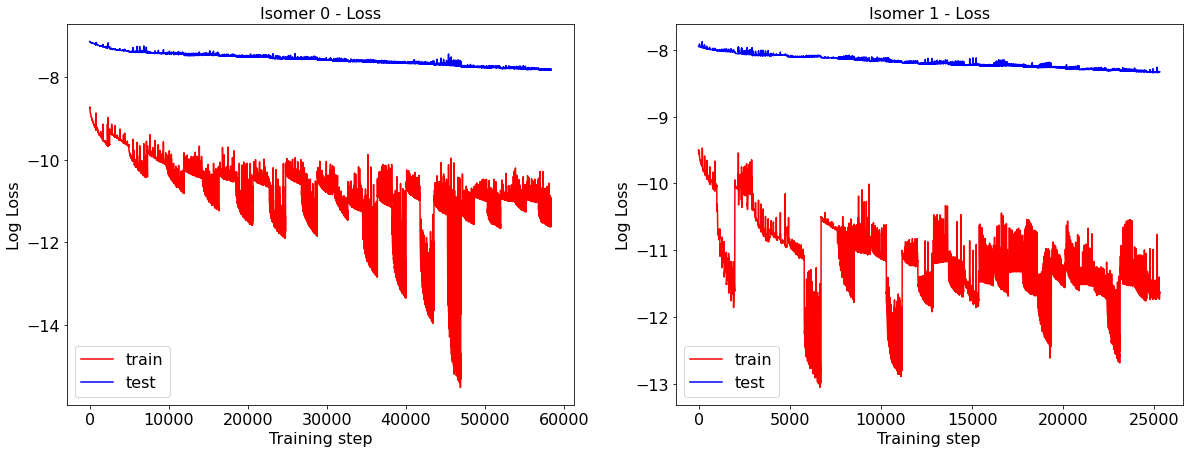

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7))

for i in range(len(losses_mlp_train)):
    set_plot_sequential_data(torch.log(losses_mlp_train[i]), ax=axs[i], color='red', label='train', alpha=1, avg=False)
    set_plot_sequential_data(torch.log(losses_mlp_test[i]), ax=axs[i], color='blue', label='test', alpha=1, avg=False)

    axs[i].set_xlabel('Training step')
    axs[i].set_ylabel('Log Loss')
    axs[i].set_title(f'Isomer {i} - Loss')

    axs[i].legend()

## 1.b Flow loss

In [12]:
losses_dft = [torch.cat([adaptives_mcmc_dft[i]['dict_flows_training'][j][0]['losses'][0]
                            for j in range(len(adaptives_mcmc_dft[i]['dict_flows_training']))
                            ]) 
                            for i in range(2)]
                          
losses_mlp = [torch.cat([adaptives_mcmc_mlp[i]['dict_flows_training'][j][0]['losses'][0]
                            for j in range(len(adaptives_mcmc_mlp[i]['dict_flows_training']))
                            ])
                            for i in range(2)]

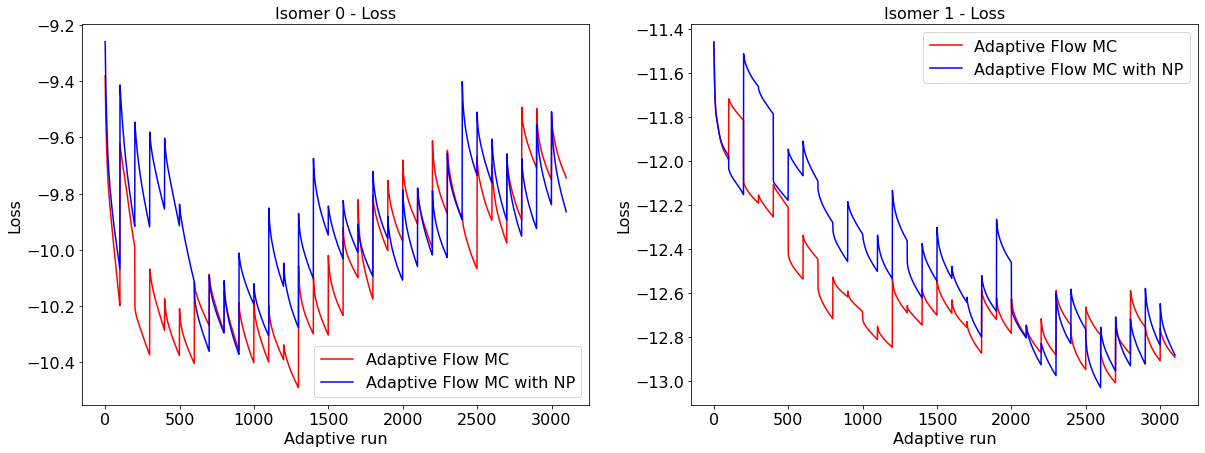

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7))

grad_steps = [1, 1]

for i in range(len(losses_dft)):
    set_plot_sequential_data(losses_dft[i], ax=axs[i], color='red', label='Adaptive Flow MC', alpha=1, avg=False)
    set_plot_sequential_data(losses_mlp[i][::grad_steps[i]], ax=axs[i], color='blue', label='Adaptive Flow MC with NP', alpha=1, avg=False)

    axs[i].set_xlabel('Adaptive run')
    axs[i].set_ylabel('Loss')
    axs[i].set_title(f'Isomer {i} - Loss')

    axs[i].legend()

## 1.c Acceptance rate

In [15]:
accs_dft = [torch.cat(adaptive_mcmc['accs']).mean(dim=1) for adaptive_mcmc in adaptives_mcmc_dft]
accs_mlp = [torch.cat(adaptive_mcmc['accs']).mean(dim=1) for adaptive_mcmc in adaptives_mcmc_mlp]

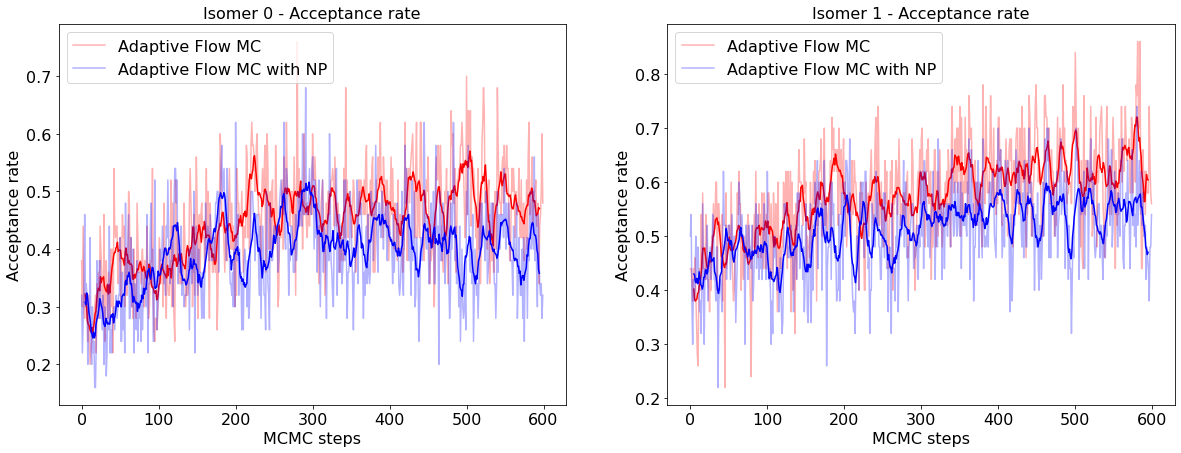

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7))

for i in range(len(accs_dft)):

    set_plot_sequential_data(accs_dft[i], ax=axs[i], color='red', label='Adaptive Flow MC')
    set_plot_sequential_data(accs_mlp[i], ax=axs[i], color='blue', label='Adaptive Flow MC with NP')

    axs[i].set_xlabel('MCMC steps')
    axs[i].set_ylabel('Acceptance rate')
    axs[i].set_title(f'Isomer {i} - Acceptance rate')

    axs[i].legend()

## 1.d $\hat{R}$ test

In [6]:
xs_dft = [torch.cat(adaptive_mcmc['xs']).detach().numpy().transpose(1, 0, 2) for adaptive_mcmc in adaptives_mcmc_dft]
xs_mlp = [torch.cat(adaptive_mcmc['xs']).detach().numpy().transpose(1, 0, 2) for adaptive_mcmc in adaptives_mcmc_mlp]

In [7]:
rhat_dft = [R_hat(x) for x in xs_dft]
rhat_mlp = [R_hat(x) for x in xs_mlp]

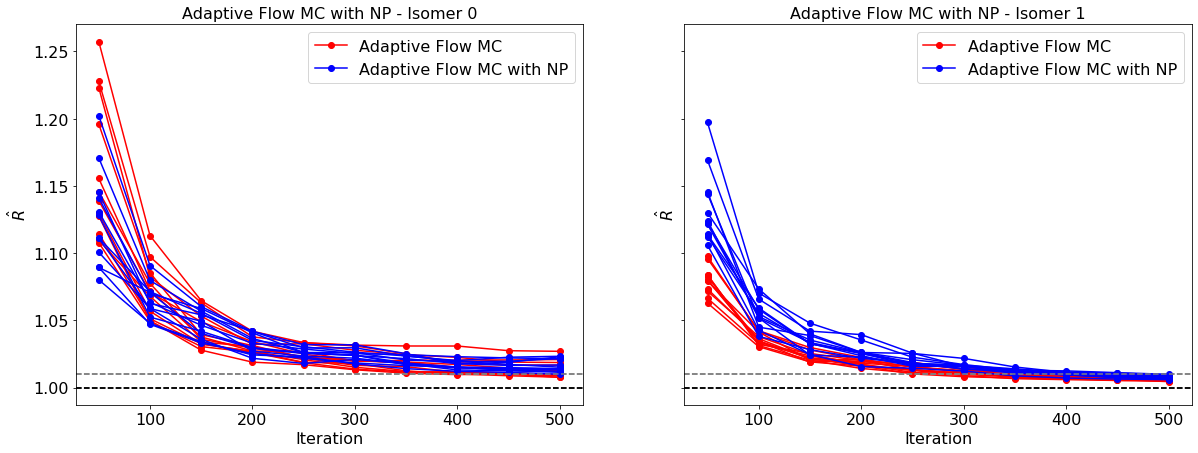

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7), sharex=True, sharey=True)

axs = axs.ravel()

for i in range(len(rhat_dft)):
    axs[i].plot(rhat_dft[i][1], rhat_dft[i][0], '-o',  label='Adaptive Flow MC', color='red')
    axs[i].axhline(1, c='k', ls='--')
    axs[i].axhline(1.01, c='grey', ls='--')
    axs[i].set_xlabel('Iteration')
    axs[i].set_ylabel(r'$\hat{R}$')
    axs[i].legend()
    axs[i].set_title('Adaptive Flow MC Isomer {}'.format(i))

    axs[i].plot(rhat_mlp[i][1], rhat_mlp[i][0], '-o',  label='Adaptive Flow MC with NP', color='blue')
    axs[i].axhline(1, c='k', ls='--')
    axs[i].axhline(1.01, c='grey', ls='--')
    axs[i].set_xlabel('Iteration')
    axs[i].set_ylabel(r'$\hat{R}$')
    axs[i].legend()
    axs[i].set_title('Adaptive Flow-NP MC - Isomer {}'.format(i))

for i in range(2):
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    axs[i].legend(by_label.values(), by_label.keys())

In [32]:
#fig, axs = plt.subplots(2, 2, figsize=(20, 14), sharex=True, sharey=True)
#
#for i in range(len(rhat_dft)):
#    axs[i][0].plot(rhat_dft[i][1], rhat_dft[i][0], '-o',  label=rhat_dft[i][2])
#    axs[i][0].axhline(1, c='k', ls='--')
#    axs[i][0].axhline(1.01, c='grey', ls='--')
#    axs[i][0].set_xlabel('Iteration')
#    axs[i][0].set_ylabel(r'$\hat{R}$')
#    axs[i][0].legend()
#    axs[i][0].set_title('Adaptive Flow MC Isomer {}'.format(i))
#
#    axs[i][1].plot(rhat_mlp[i][1], rhat_mlp[i][0], '-o',  label=rhat_mlp[i][2])
#    axs[i][1].axhline(1, c='k', ls='--')
#    axs[i][1].axhline(1.01, c='grey', ls='--')
#    axs[i][1].set_xlabel('Iteration')
#    axs[i][1].set_ylabel(r'$\hat{R}$')
#    axs[i][1].legend()
#    axs[i][1].set_title('Adaptive Flow MC with NP Isomer {}'.format(i))

## 1.e Collective variables

In [21]:
coord_mapping = Coordinates_mapping(etype='dft')

xs_dft = [torch.cat(adaptive_mcmc['xs']).detach() for adaptive_mcmc in adaptives_mcmc_dft]
xs_mlp = [torch.cat(adaptive_mcmc['xs']).detach() for adaptive_mcmc in adaptives_mcmc_mlp]

In [22]:
C_dft = []
R_dft = []

for i in range(len(xs_dft)):
    
    C = []
    R = []

    for j in range(xs_dft[i].shape[0]):

        cvs = coord_mapping.get_collective_variables_from_real_centered(xs_dft[i][j], isomer=i)
        C.append(cvs[:, 0].flatten())
        R.append(cvs[:, 1].flatten())

    C_dft.append(torch.stack(C))
    R_dft.append(torch.stack(R))

In [23]:
C_mlp = []
R_mlp = []

for i in range(len(xs_mlp)):
    
    C = []
    R = []

    for j in range(xs_mlp[i].shape[0]):

        cvs = coord_mapping.get_collective_variables_from_real_centered(xs_mlp[i][j], isomer=i)
        C.append(cvs[:, 0].flatten())
        R.append(cvs[:, 1].flatten())

    C_mlp.append(torch.stack(C))
    R_mlp.append(torch.stack(R))

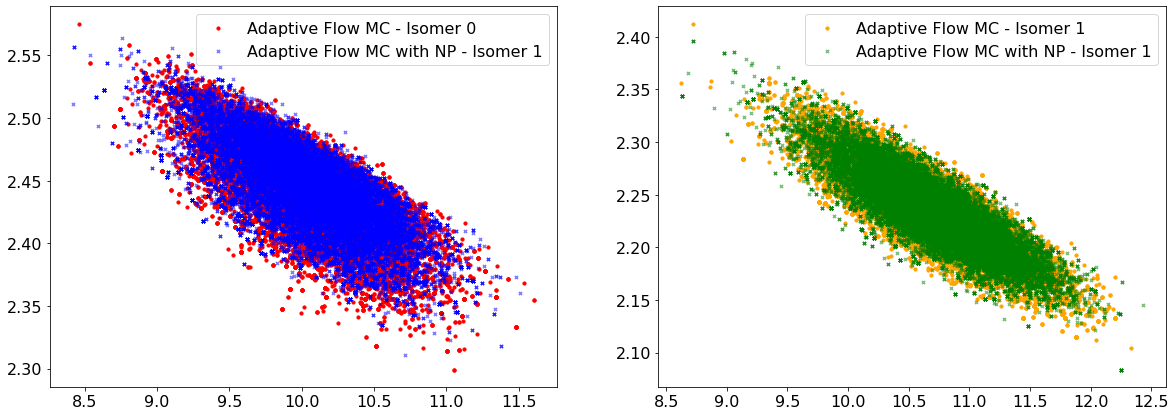

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(20, 7))

ax[0].scatter(C_dft[0].flatten().detach().numpy(), R_dft[0].flatten().detach().numpy(), s=10, c='red', label='Adaptive Flow MC - Isomer 0')
ax[0].scatter(C_mlp[0].flatten().detach().numpy(), R_mlp[0].flatten().detach().numpy(), s=10, c='blue', label='Adaptive Flow MC with NP - Isomer 1', marker='x', alpha=0.5)

ax[1].scatter(C_dft[1].flatten().detach().numpy(), R_dft[1].flatten().detach().numpy(), s=10, c='orange', label='Adaptive Flow MC - Isomer 1')
ax[1].scatter(C_mlp[1].flatten().detach().numpy(), R_mlp[1].flatten().detach().numpy(), s=10, c='green', label='Adaptive Flow MC with NP - Isomer 1', marker='x', alpha=0.5)

ax[0].legend()
ax[1].legend()

## 1.e Energy histograms

In [26]:
us_dft = [torch.cat(adaptive_mcmc['us']) for adaptive_mcmc in adaptives_mcmc_dft]
us_mlp = [torch.cat(adaptive_mcmc['us']) for adaptive_mcmc in adaptives_mcmc_mlp]

In [27]:
dfs = [{'Adaptive Flow MC': us_dft[i].flatten().detach(), 
        'Adaptive Flow MC with NP': us_mlp[i].flatten().detach()} for i in range(2)]

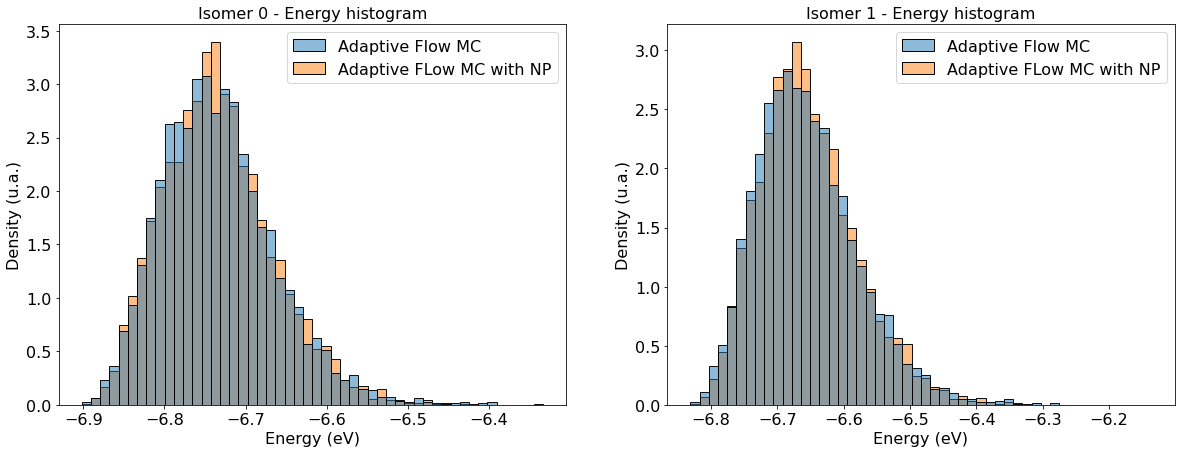

In [28]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7))

for i in range(2):
    plot_energy_histogram(dfs[i], ax=axs[i], bins=50, alpha=0.5)
    axs[i].set_title(f'Isomer {i} - Energy histogram')

# 2. MCMC

In [116]:
# simulation files
mcmc_paths = ['5-multimodal/results_multimodal_sampling_mixture_29096190/mixture_mcmc_dic_29096190.pkl',
            '6-multimodal-mlp/results_multimodal_sampling_mixture_29821740/mixture_mcmc_dic_29821740.pkl',
            '6-multimodal-mlp/results_multimodal_sampling_mixture_29821741/mixture_mcmc_dic_29821741.pkl' ]

mcmc_paths_long_sims = [#'5-multimodal/results_multimodal_sampling_mixture_29096190/mixture_mcmc_dic_29096190.pkl',
            '6-multimodal-mlp/results_multimodal_sampling_mixture_29821840/mixture_mcmc_dic_29821840.pkl',
            '6-multimodal-mlp/results_multimodal_sampling_mixture_29821841/mixture_mcmc_dic_29821841.pkl' ]

# load mcmc results
keys = ['DFT only', 'Flow MC + NP', 'Flow-NP MC + NP']
color_keys = dict(zip(keys, ['blue', 'orange', 'red']))
mcmcs = {key: load_pickle_file(mcmc_path, DFT_SIMS_PATH) for mcmc_path, key in zip(mcmc_paths, keys)}
mcmcs_long = {key: load_pickle_file(mcmc_path, DFT_SIMS_PATH) for mcmc_path, key in zip(mcmc_paths_long_sims, keys[1:])}

## 2.a Acceptance rate

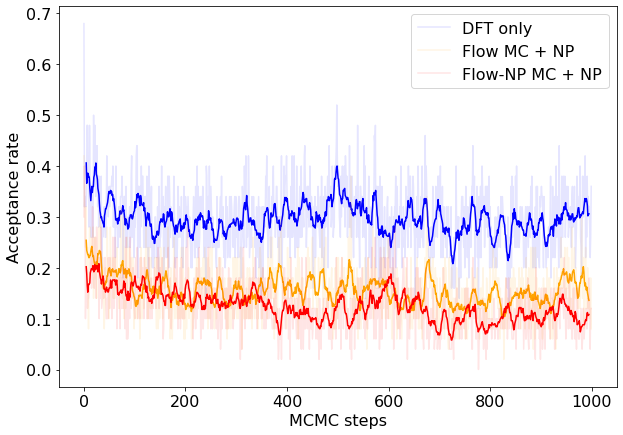

In [117]:
accs = {key: mcmcs[key]['accs'].mean(dim=1).detach() for key in mcmcs.keys()}

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

for key in accs.keys():

    set_plot_sequential_data(accs[key], ax=ax, label=key, alpha=0.1, color=color_keys[key])
    ax.set_xlabel('MCMC steps')
    ax.set_ylabel('Acceptance rate')

ax.legend()

### 2.a.1 Acceptance rate histograms

In [107]:
accs_window = {}

for key in accs.keys():
    accs_window[key] = dict(zip(list(range(0, 4)), accs[key].reshape(4, 250).reshape(4, -1) ))

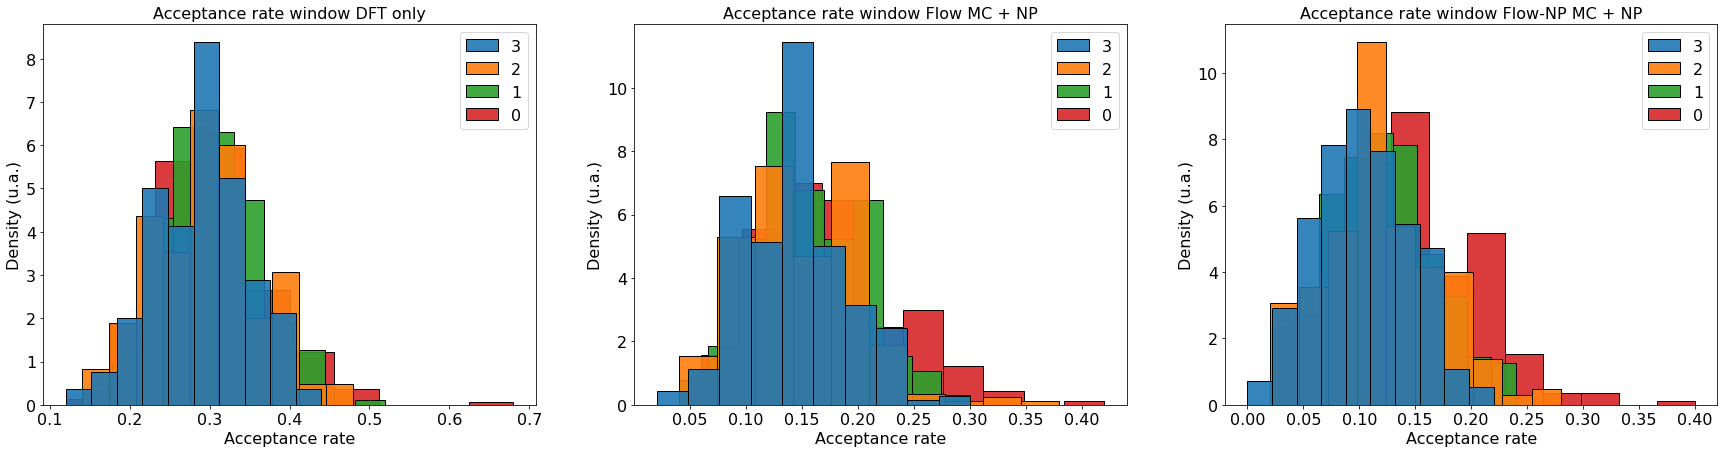

In [108]:
fig, axs = plt.subplots(1, 3, figsize=(30, 7))

for i, key in enumerate(keys):
    plot_energy_histogram(accs_window[key], ax=axs[i], bins=10, alpha=0.9, common_bins=False, common_norm=False, hue_order=list(range(0, 4))[::-1])
    
    axs[i].set_title('Acceptance rate window {:s}'.format(key))
    axs[i].set_xlabel('Acceptance rate')

## 2.b Collective variables

In [215]:
def get_collective_variable(simulation, etype='dft'):

    coord_mapping = Coordinates_mapping(etype=etype)

    xs = simulation['xs']
    xs_flatten = xs.reshape(-1, 12)

    isomers_mask = simulation['isomers'].reshape(-1, 1)

    xs_is0 = []
    xs_is1 = []

    for isomer, x in zip(isomers_mask, xs_flatten):
        if isomer==0:
            xs_is0.append(x)
        elif isomer==1:
            xs_is1.append(x)
        else:
            raise Warning('Not found!')

    xs_is0 = torch.stack(xs_is0)
    xs_is1 = torch.stack(xs_is1)

    cvs_is0 = coord_mapping.get_collective_variables_from_real_centered(xs_is0, isomer=0)
    cvs_is1 = coord_mapping.get_collective_variables_from_real_centered(xs_is1, isomer=1)

    return cvs_is0, cvs_is1

In [216]:
cvs = {key: get_collective_variable(mcmcs[key]) for key in mcmcs.keys()}

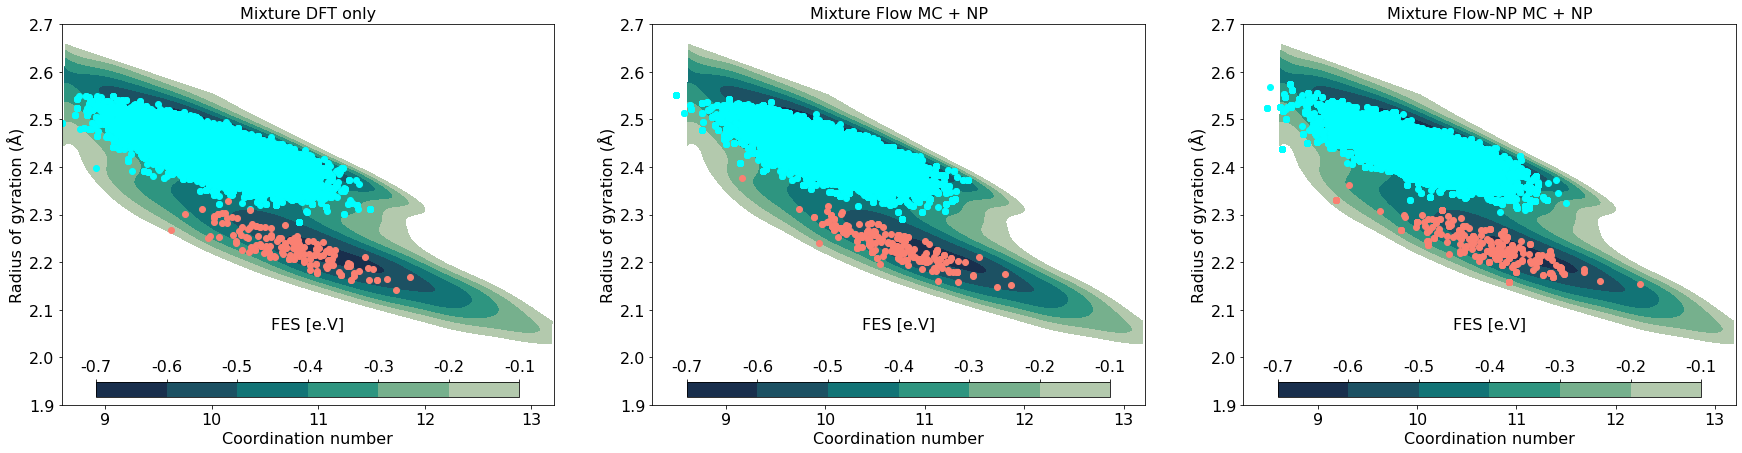

In [217]:
fig, axs = plt.subplots(1, 3, figsize=(30, 7))

axs = axs.ravel()

for ax, key in zip(axs, cvs.keys()):

    plot_energy_surface(fig=fig, ax=ax)

    ax.scatter(cvs[key][0][:, 0], cvs[key][0][:, 1], c='cyan')
    ax.scatter(cvs[key][1][:, 0], cvs[key][1][:, 1], c='salmon')
    ax.set_title('Mixture {:s}'.format(key))

## 2.c Jumps between isomers

In [13]:
def plot_jums_along_chains(ax, isomers, size=6):

    isomers = isomers.T

    for i in range(isomers.shape[0]):

        jumps, counts = isomers[i].unique_consecutive(return_counts=True)

        colors_array = []
        
        for j in range(jumps.shape[0]):
            if jumps[j]==0:
                colors_array.append('cyan')
            else:
                colors_array.append('salmon')
        
        ax.plot(torch.ones(jumps.shape[0])*i, np.arange(0, jumps.shape[0]), 'k--', alpha=0.4)
        ax.scatter(torch.ones(jumps.shape[0])*i, np.arange(0, jumps.shape[0]), s=counts*size, color=colors_array)
    
    ax.set_xlabel('Chains')
    ax.set_ylabel('Jumps')

In [14]:
isomers = {key: mcmcs[key]['isomers'] for key in mcmcs.keys()}

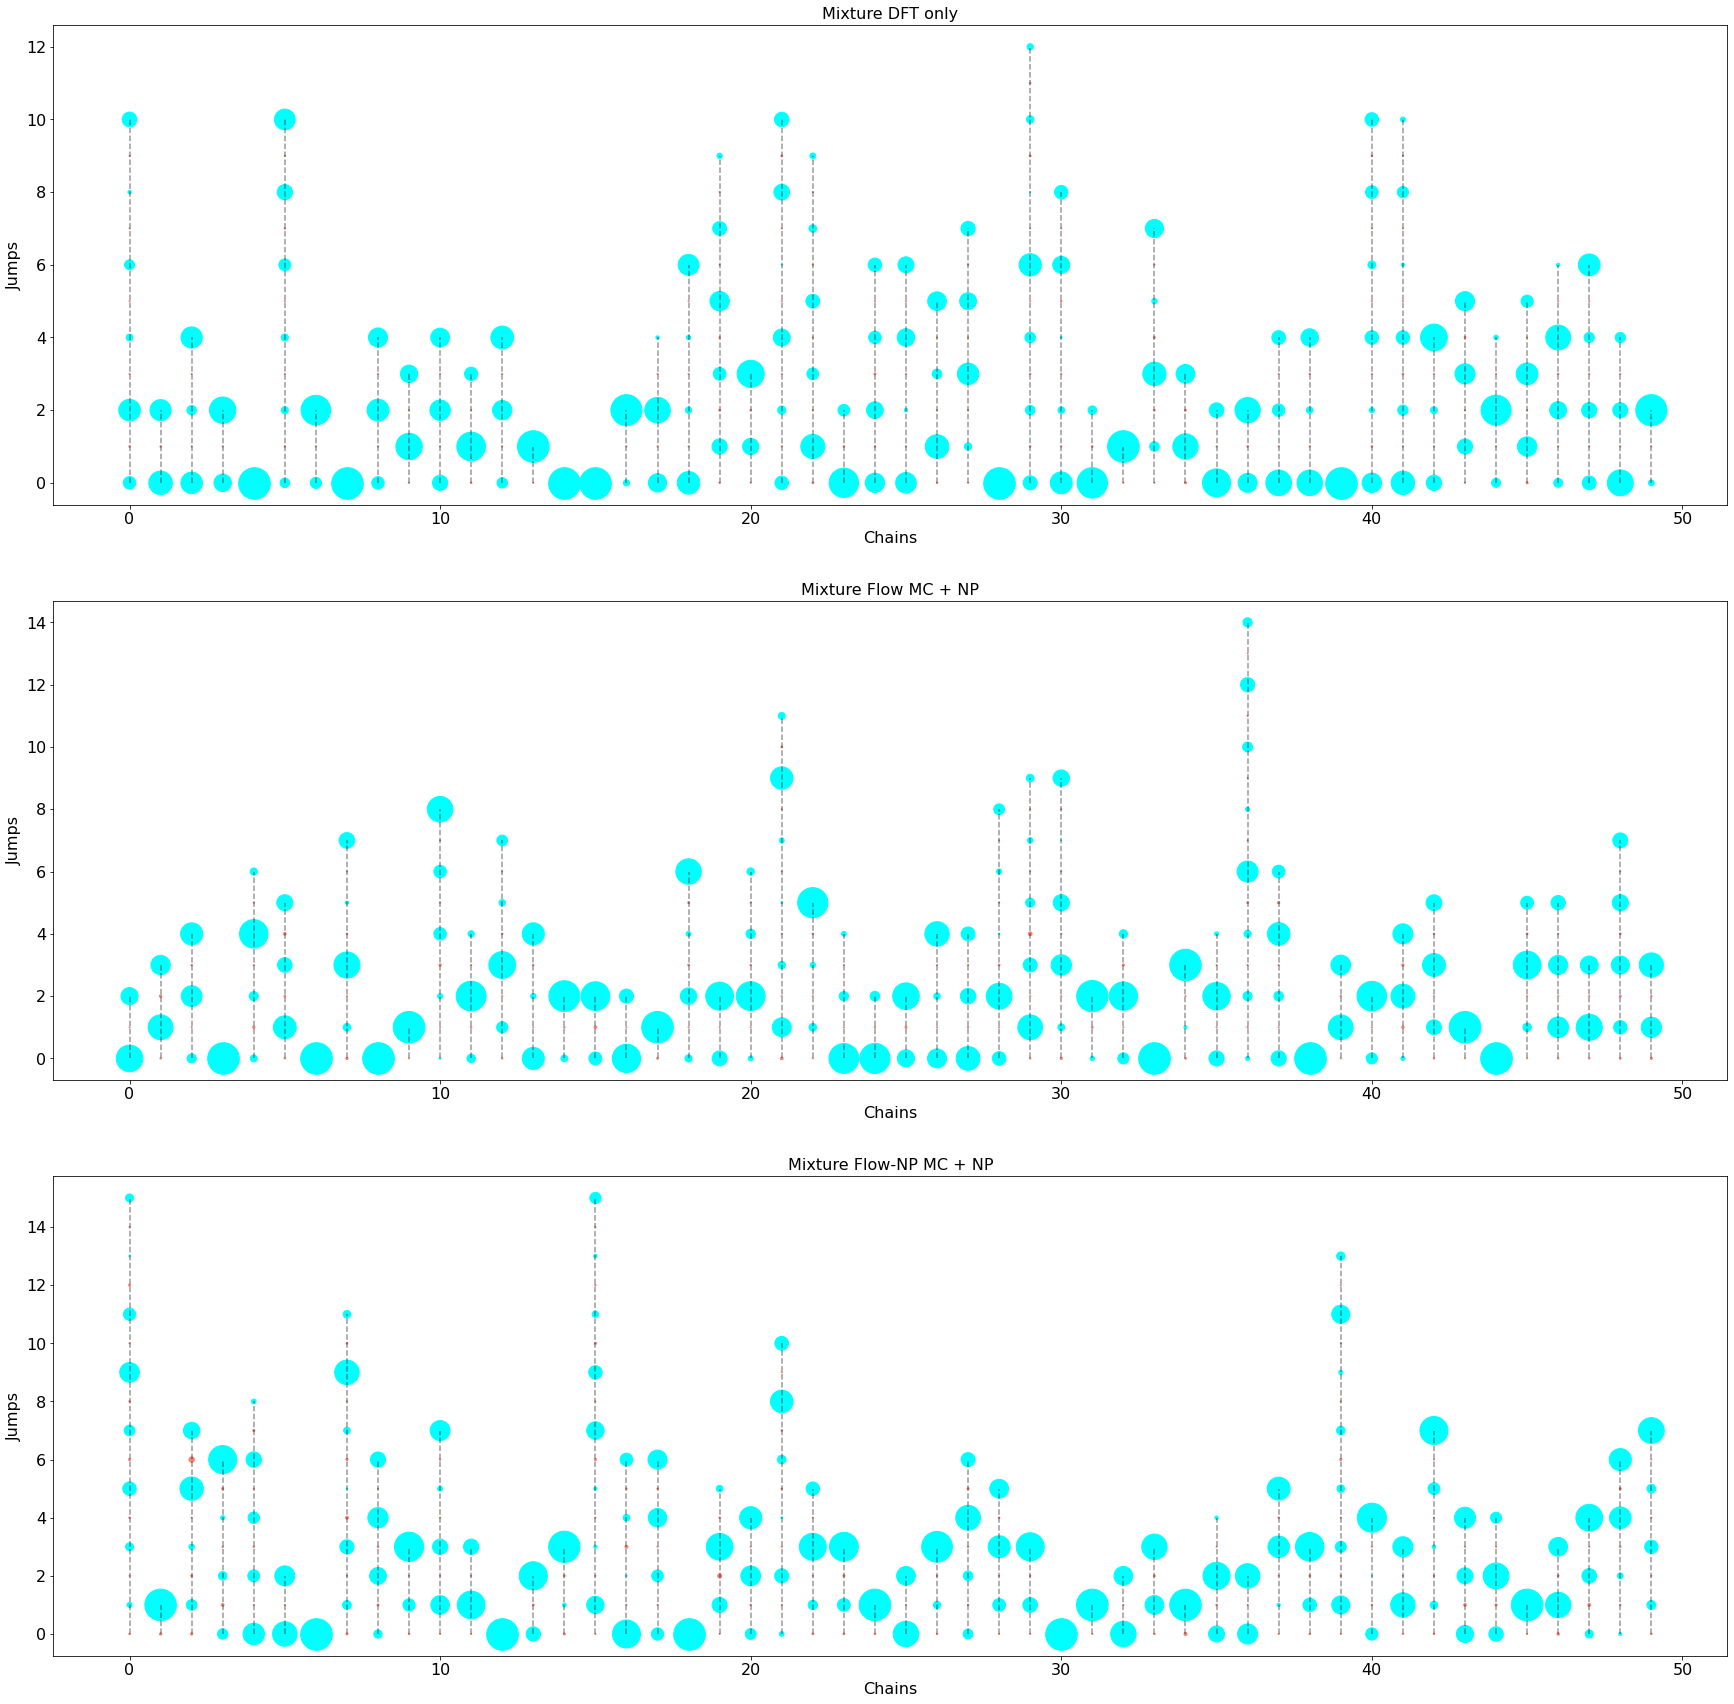

In [15]:
fig, axs = plt.subplots(3, 1, figsize=(30, 30))

axs = axs.ravel()

for ax, key in zip(axs, isomers.keys()):
    plot_jums_along_chains(ax, isomers[key], size=1)

    ax.set_title('Mixture {:s}'.format(key))

In [ ]:
jumps, counts = isomers[i].unique_consecutive(return_counts=True)


In [16]:
def plot_jumps_along_steps(ax, isomers):

    ax.plot(isomers.detach().numpy(), '.-')
    ax.set_xlabel('MCMC steps')
    ax.set_ylabel('Isomer')

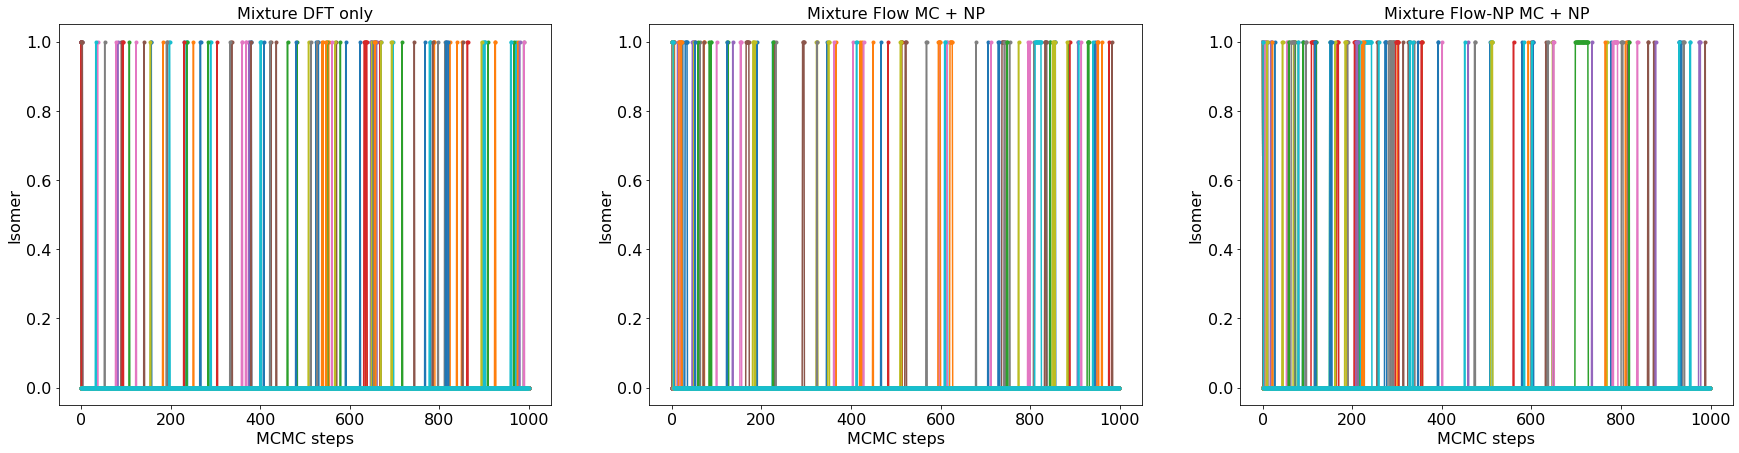

In [17]:
fig, axs = plt.subplots(1, 3, figsize=(30, 7))

axs = axs.ravel()

for ax, key in zip(axs, isomers.keys()):
    plot_jumps_along_steps(ax, isomers[key])

    ax.set_title('Mixture {:s}'.format(key))

## 2.c Rhat test

In [124]:
time_mcmc = {}
time_mcmc_window = {}

for key in mcmcs.keys():
    time_list = mcmcs[key]['time_mcmc']
    time_init = time_list[0]
    final_time = [(t - time_init)/3600 for t in time_list]
    time_mcmc[key] = final_time
    time_mcmc_window[key] = sliding_window_view(final_time, 100, axis=0).mean(axis=1)

In [125]:
def get_zmat_from_real(xs, isomers, etype='dft'):

    xs = xs.clone().detach().numpy().transpose(1, 0, 2)
    isomers = isomers.clone().detach().numpy().transpose(1, 0)

    coord_mapping = Coordinates_mapping(etype=etype)

    zmat = torch.zeros(xs.shape)

    for i in range(xs.shape[1]):
        for j in range(xs.shape[0]):
            zmat[j, i] = coord_mapping.get_internal_from_real_centered(torch.tensor(xs[j, i]).reshape(1, -1), 
                                                                        isomer=isomers[j, i])[0]
    zmat = zmat.clone().detach().numpy()

    return zmat

In [126]:
def plot_rhat(ax, rhat):

    ax.plot(rhat[1], rhat[0], '-o',  label=rhat[2])
    ax.axhline(1, c='k', ls='--')
    ax.axhline(1.01, c='grey', ls='--')
    ax.set_xlabel('Iteration')
    ax.set_ylabel(r'$\hat{R}$')

In [195]:
xs = {key: mcmcs[key]["xs"].detach() for key in mcmcs.keys()}

In [196]:
zmats = {key: get_zmat_from_real(xs[key], isomers[key]) for key in xs.keys()}

rhat_s = {key: R_hat(zmats[key], n_split=10) for key in keys}

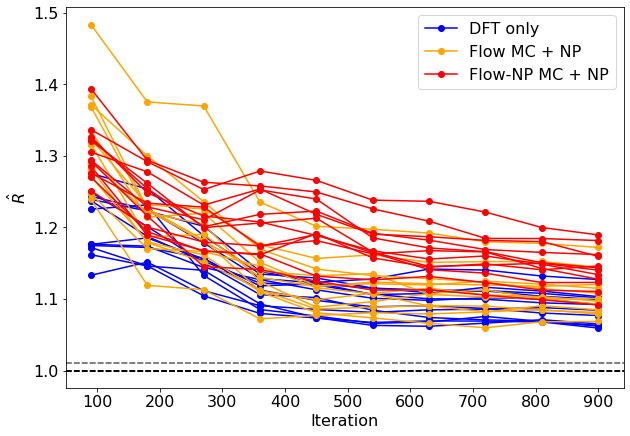

In [197]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
for key in rhat_s.keys():
    ax.plot(rhat_s[key][1], rhat_s[key][0], '-o',  label=key, color=color_keys[key])
    ax.axhline(1, c='k', ls='--')
    ax.axhline(1.01, c='grey', ls='--')
    ax.set_xlabel('Iteration')
    ax.set_ylabel(r'$\hat{R}$')
    #ax.set_xscale('log')

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))

    ax.legend(by_label.values(), by_label.keys())

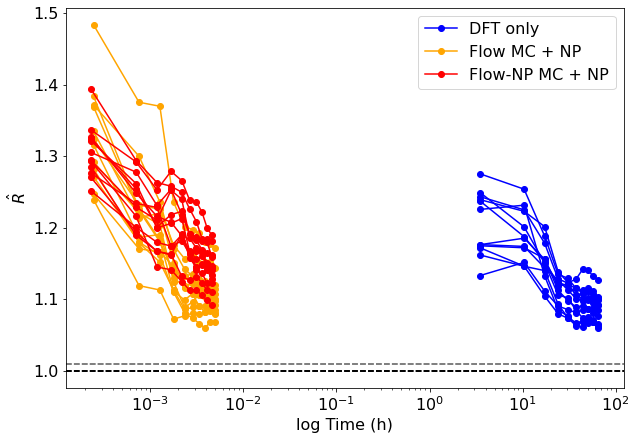

In [198]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7), sharey=True)

for key in rhat_s.keys():
    ax.plot(time_mcmc_window[key][::100], rhat_s[key][0], '-o',  label=key, color=color_keys[key])
    ax.axhline(1, c='k', ls='--')
    ax.axhline(1.01, c='grey', ls='--')
    ax.set_xlabel('log Time (h)')
    ax.set_ylabel(r'$ \hat{R}$')
    ax.set_xscale('log')

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))

    ax.legend(by_label.values(), by_label.keys())

## 2.d Energies

Text(0.5, 1.0, 'Energy histogram')

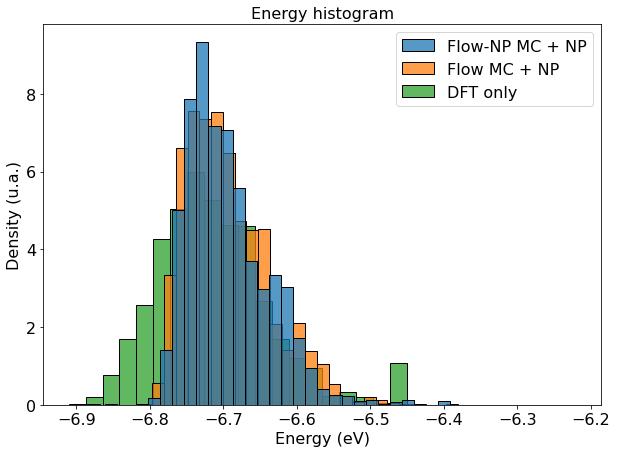

In [205]:
us = {key: mcmcs[key]['us'].flatten().detach() for key in mcmcs.keys()}

fig, axs = plt.subplots(1, 1, figsize=(10, 7))

plot_energy_histogram(us, ax=axs, bins=30, alpha=0.75, hue_order=keys[::-1], common_bins=False, common_norm=False, color=color_keys)
axs.set_title(f'Energy histogram')

### 2.d.1 Neural predictors

In [48]:
mlp_label_keys = ['_adaptive', '_adaptive_mlp']
mlps = [{key: load_pickle_file('dict_mlp_model_is{:d}{:s}.pkl'.format(i, tag), get_path() + '/andersen/models') for key, tag in zip(keys[1:], mlp_label_keys)} for i in [0, 1]]

In [80]:
#mlps[0][keys[1]]['args']

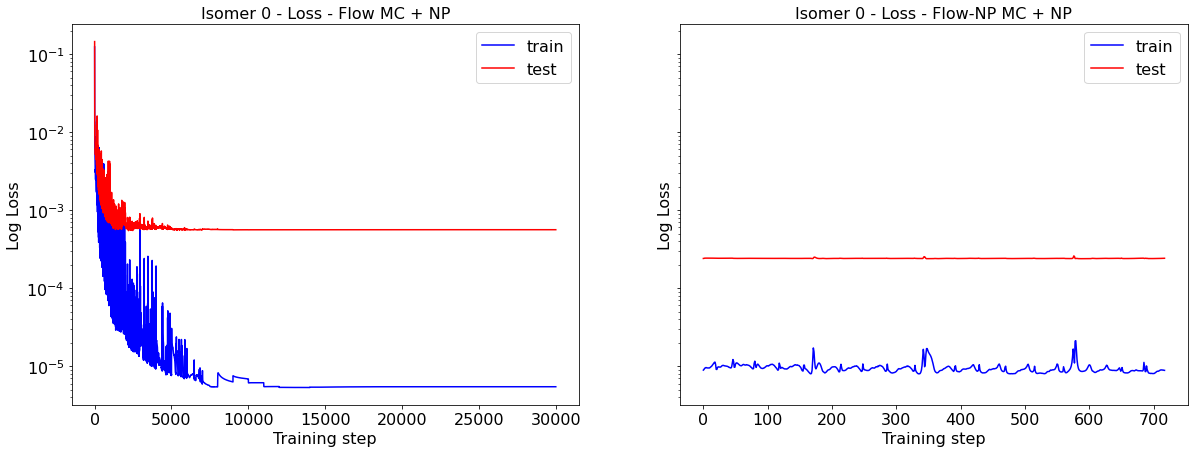

In [81]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

for i, key in enumerate(mlps[0].keys()):
    set_plot_sequential_data(np.array(mlps[i][key]['train_loss']), ax=axs[i], color='blue', label='train', alpha=1, avg=False)
    set_plot_sequential_data(np.array(mlps[i][key]['test_loss']), ax=axs[i], color='red', label='test', alpha=1, avg=False)
    axs[i].set_xlabel('Training step')
    axs[i].set_ylabel('Log Loss')
    axs[i].set_title(f'Isomer 0 - Loss - {key}')
    axs[i].set_yscale('log')

    axs[i].legend()

In [82]:
xs = mcmcs[keys[0]]['xs']
isomers = mcmcs[keys[0]]['isomers']
us = mcmcs[keys[0]]['us']

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or R

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or R

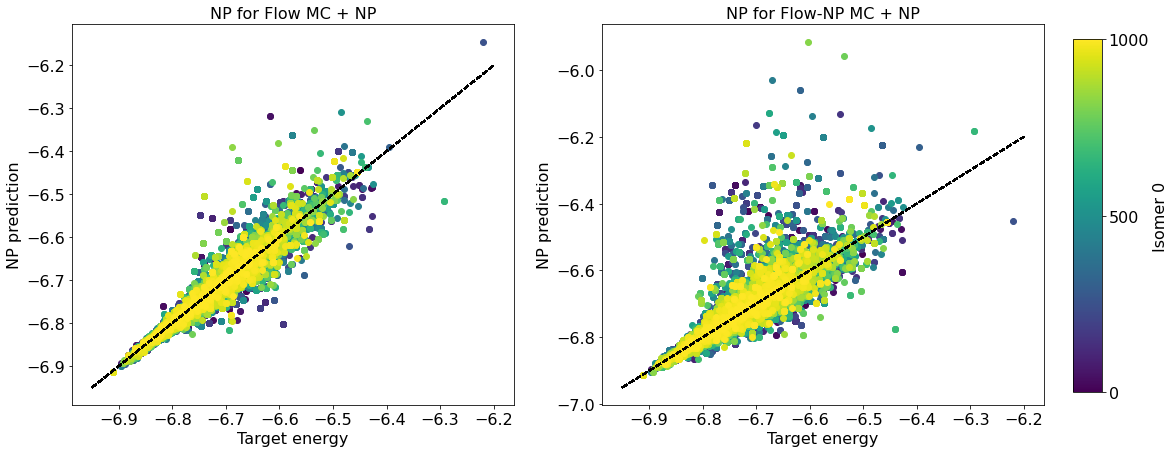

In [78]:
cmap_name = 'viridis'
cmap = plt.get_cmap(cmap_name)
num_colors = 1000
values = np.linspace(0, 1, num_colors)
colors = cmap(values)

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

for key, ax in zip(keys[1:], axs):
    for i in range(1000):   
        ax.scatter(us[i][isomers[i]==0].flatten().detach(), mlps[0][key]['model'](xs[i][isomers[i]==0]).flatten().detach(), c=colors[i])
        ax.set_xlabel('Target energy')
        ax.set_ylabel('NP prediction')
        ax.set_title('NP for {:s}'.format(key))
        ax.plot([-6.95, -6.2], [-6.95, -6.2], 'k--')
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.82, 0.15, 0.02, 0.7])
cbar = fig.colorbar(ax.collections[0], cax=cbar_ax)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels([0, 500, 1000])
cbar.set_label('Isomer 0')

## 2.e Populations

In [209]:
isomers = {key: mcmcs[key]['isomers'] for key in mcmcs.keys()}

In [212]:
#population = {key: sliding_window_view(isomers[key].detach(), (50, 50)).squeeze().reshape(951, -1).mean(axis=1) for key in keys}

In [213]:
#fig, ax = plt.subplots(1, 1, figsize=(10, 7))
#
#for key in population.keys():
#    set_plot_sequential_data(population[key], ax=ax, avg=True, label=key, window_size=100, alpha=0.3, color=color_keys[key])
#    ax.set_xlabel('MCMC steps')
#    ax.set_ylabel('Isomer population')
#    ax.legend()

(0.0, 0.03)

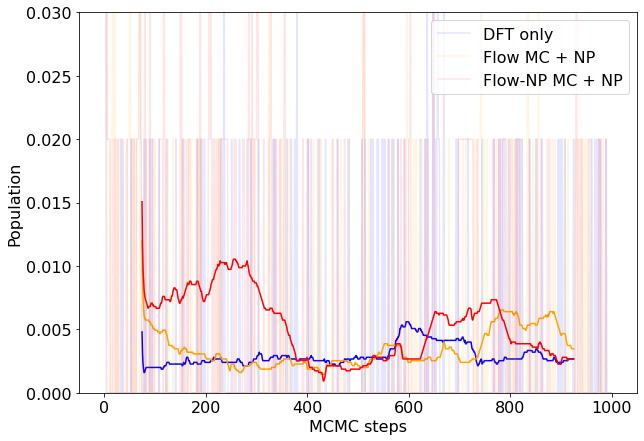

In [191]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

for key in keys:
    set_plot_sequential_data(isomers[key].mean(dim=1).detach(), avg=True, window_size=150, ax=ax, label=key, color=color_keys[key], alpha=0.1)

ax.set_xlabel('MCMC steps')
ax.set_ylabel('Population')
ax.legend()

ax.set_ylim(0, 0.03)

## 3. 10000 steps simulations

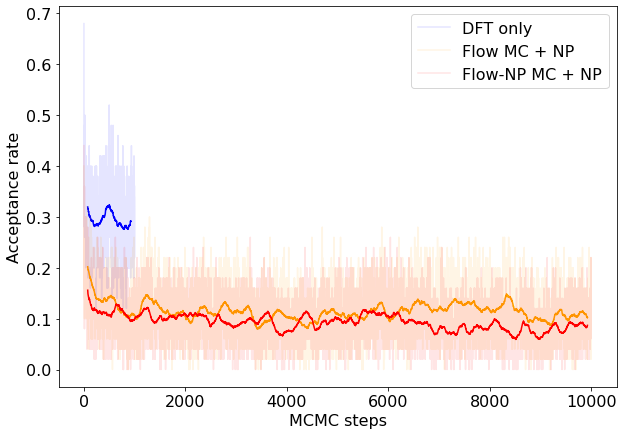

In [131]:
accs_long = {key: mcmcs_long[key]['accs'].mean(dim=1).detach() for key in mcmcs_long.keys()}

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

set_plot_sequential_data(accs[keys[0]], ax=ax, alpha=0.1, window_size=150, label=keys[0], color=color_keys[keys[0]])

for key in mcmcs_long.keys():

    set_plot_sequential_data(accs_long[key], ax=ax, alpha=0.1, window_size=150, label=key, color=color_keys[key])
    ax.set_xlabel('MCMC steps')
    ax.set_ylabel('Acceptance rate')

ax.legend()

In [132]:
time_mcmc_long = {}
time_mcmc_window_long = {}

for key in mcmcs_long.keys():
    time_list = mcmcs_long[key]['time_mcmc']
    time_init = time_list[0]
    final_time = [(t - time_init)/3600 for t in time_list]
    time_mcmc_long[key] = final_time
    time_mcmc_window_long[key] = sliding_window_view(final_time, 100, axis=0).mean(axis=1)

In [133]:
xs_long = {key: mcmcs_long[key]["xs"].detach() for key in mcmcs_long.keys()}
isomers_long = {key: mcmcs_long[key]["isomers"].detach() for key in mcmcs_long.keys()}

zmats_long = {key: get_zmat_from_real(xs_long[key], isomers_long[key]) for key in xs_long.keys()}

rhat_s_long = {key: R_hat(zmats_long[key], n_split=100) for key in xs_long.keys()}

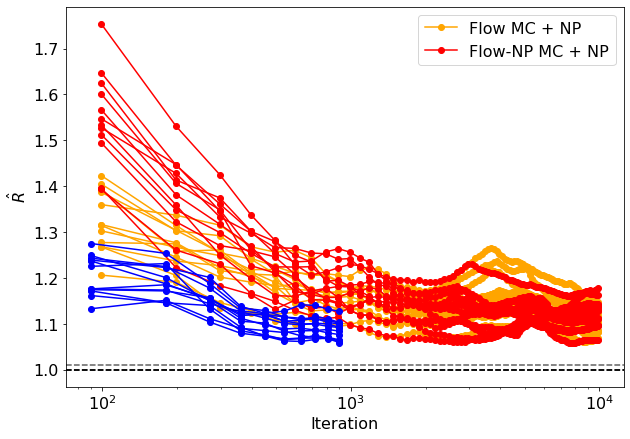

In [143]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))


for key in rhat_s_long.keys():
    ax.plot(rhat_s_long[key][1], rhat_s_long[key][0], '-o',  label=key, color=color_keys[key])
    ax.axhline(1, c='k', ls='--')
    ax.axhline(1.01, c='grey', ls='--')
    ax.set_xlabel('Iteration')
    ax.set_ylabel(r'$\hat{R}$')
    ax.set_xscale('log')

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))

    ax.legend(by_label.values(), by_label.keys())

ax.plot(rhat_s[keys[0]][1], rhat_s[keys[0]][0], '-o',  label=key, color=color_keys[keys[0]])

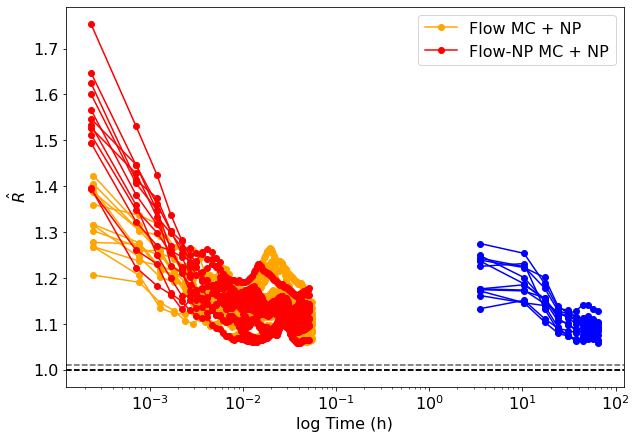

In [142]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7), sharey=True)

for key in rhat_s_long.keys():
    ax.plot(time_mcmc_window_long[key][::100], rhat_s_long[key][0], '-o',  label=key, color=color_keys[key])
    ax.axhline(1, c='k', ls='--')
    ax.axhline(1.01, c='grey', ls='--')
    ax.set_xlabel('log Time (h)')
    ax.set_ylabel(r'$ \hat{R}$')
    ax.set_xscale('log')

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))

    ax.legend(by_label.values(), by_label.keys())

ax.plot(time_mcmc_window[keys[0]][::100], rhat_s[keys[0]][0], '-o',  label=key, color=color_keys[keys[0]])


In [192]:
isomers_long = {key: mcmcs_long[key]['isomers'] for key in mcmcs_long.keys()}

(0.0, 0.05)

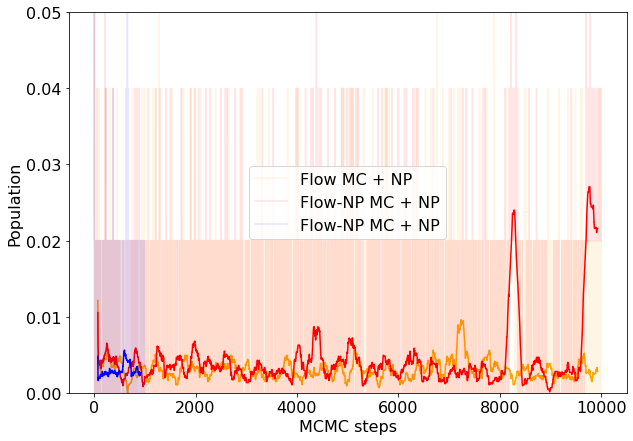

In [194]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

for key in mcmcs_long.keys():
    set_plot_sequential_data(isomers_long[key].mean(dim=1).detach(), avg=True, window_size=150, ax=ax, label=key, color=color_keys[key], alpha=0.1)
set_plot_sequential_data(isomers[keys[0]].mean(dim=1).detach(), avg=True, window_size=150, ax=ax, label=key, color=color_keys[keys[0]], alpha=0.1)

ax.set_xlabel('MCMC steps')
ax.set_ylabel('Population')
ax.legend()

ax.set_ylim(0, 0.05)

Text(0.5, 1.0, 'Energy histogram')

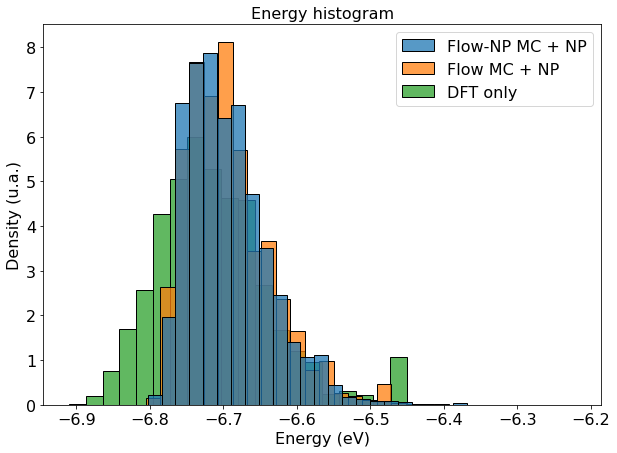

In [219]:
us_long = {key: mcmcs_long[key]['us'].flatten().detach() for key in mcmcs_long.keys()}

fig, axs = plt.subplots(1, 1, figsize=(10, 7))
us_long[keys[0]] = us[keys[0]]
plot_energy_histogram(us_long, ax=axs, bins=30, alpha=0.75, hue_order=keys[::-1], common_bins=False, common_norm=False, color=color_keys)
axs.set_title(f'Energy histogram')

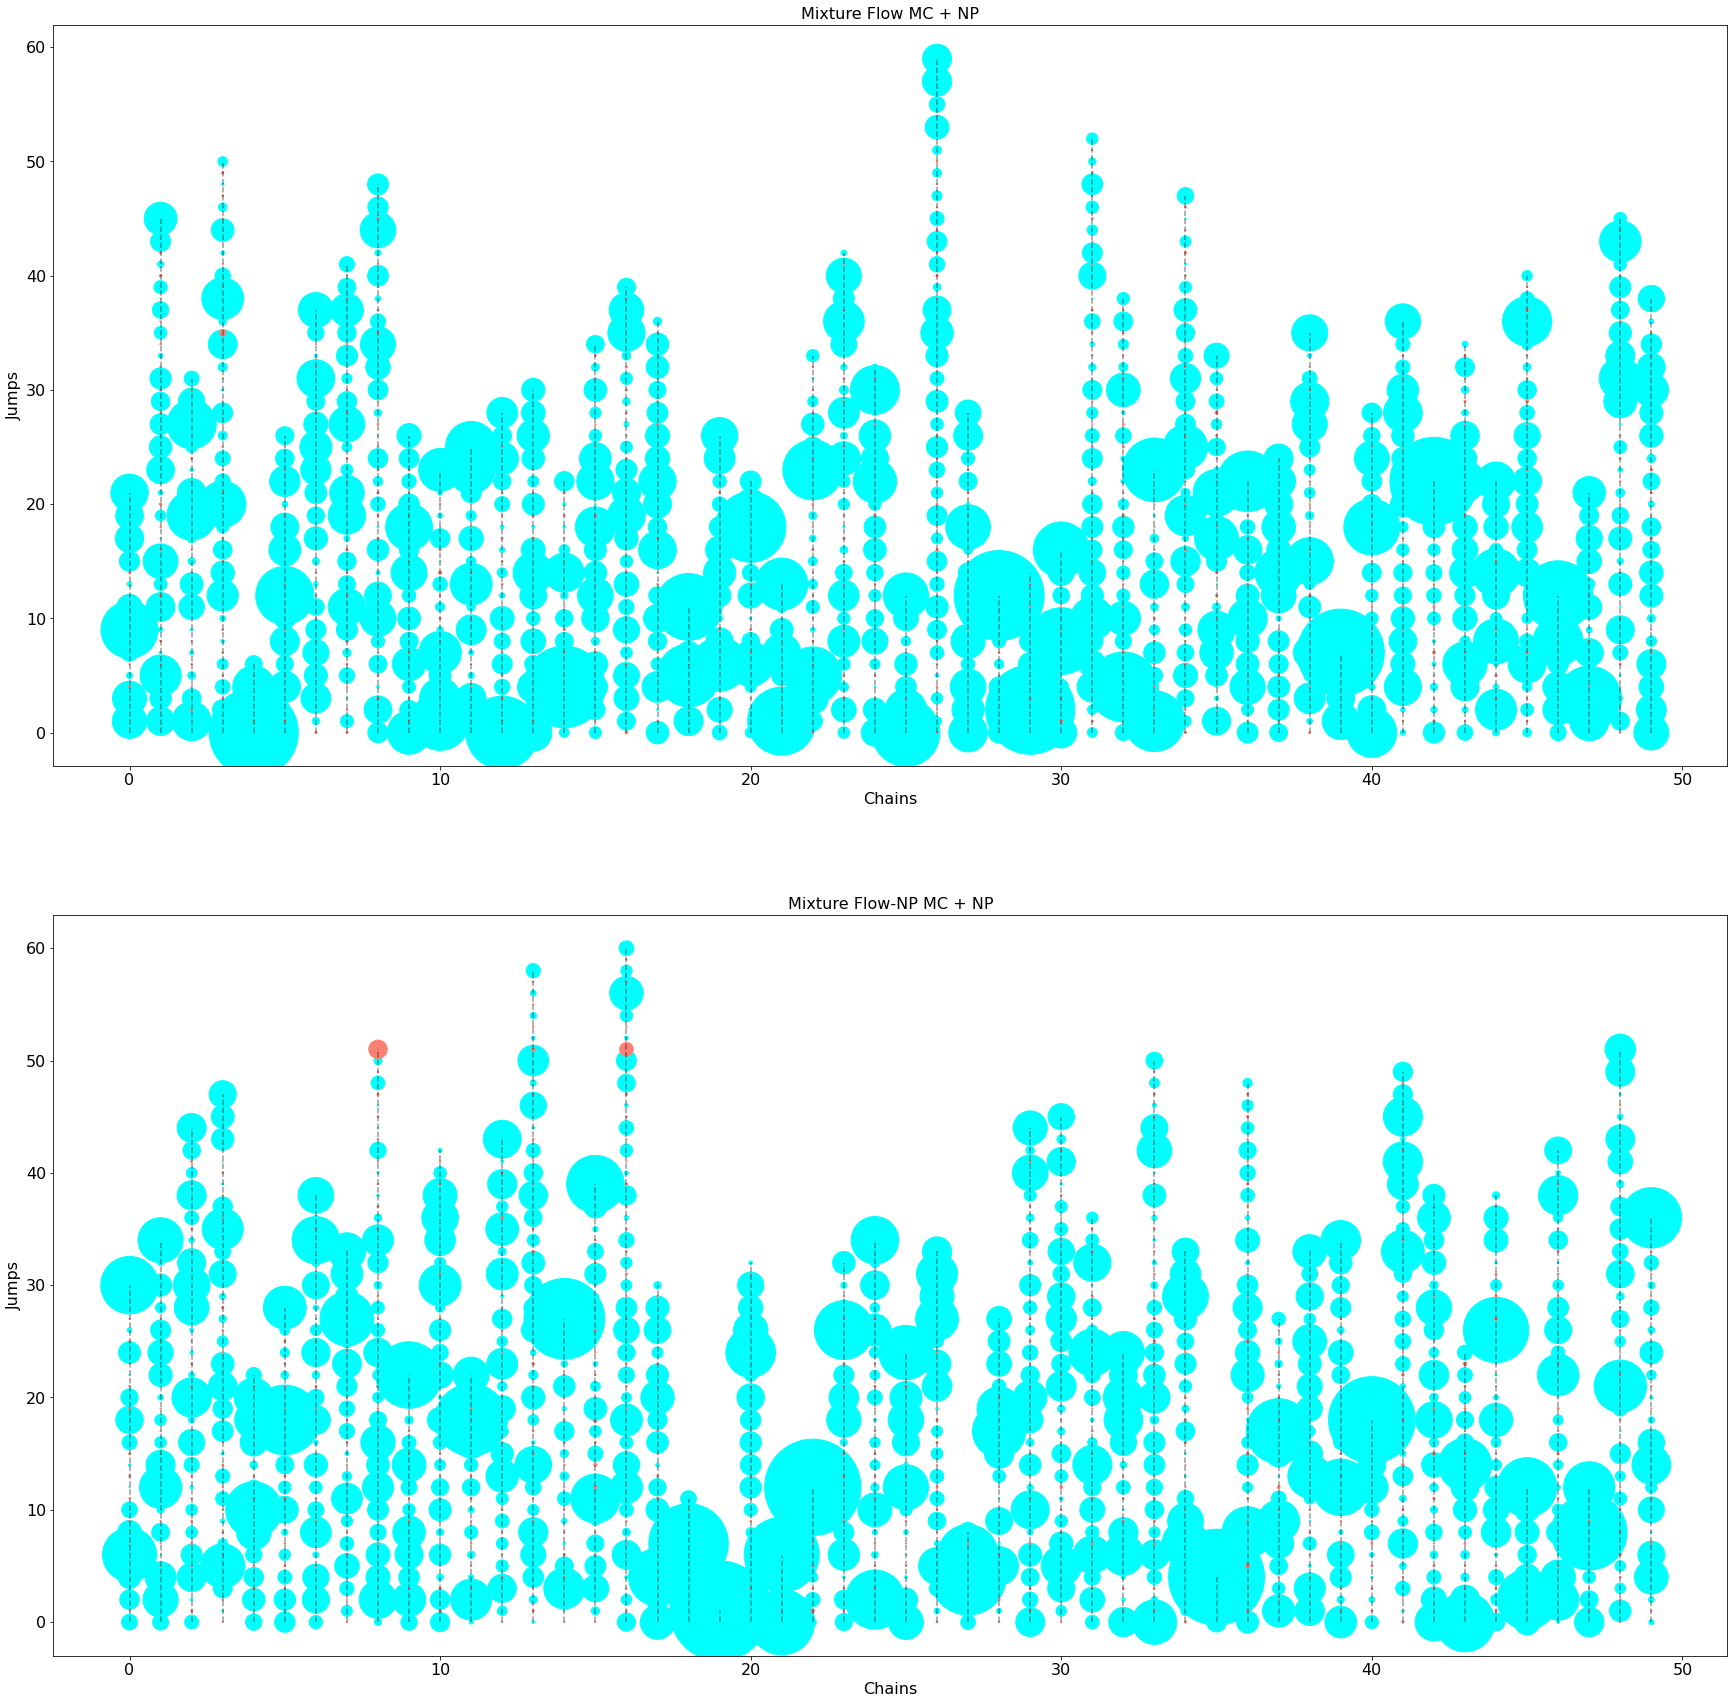

In [218]:
fig, axs = plt.subplots(2, 1, figsize=(30, 30))

axs = axs.ravel()

for ax, key in zip(axs, isomers_long.keys()):
    plot_jums_along_chains(ax, isomers_long[key], size=1)

    ax.set_title('Mixture {:s}'.format(key))